In [35]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from dotenv import load_dotenv
from langgraph.checkpoint.memory import  InMemorySaver

In [36]:
load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
)
model = ChatHuggingFace(llm=llm)


In [37]:
class JokeState(TypedDict):
    topic :str
    joke:str
    explanation : str

In [38]:
def generate_joke(state:JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content
    return {'joke':response}

In [39]:
def generate_explanation(state:JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content
    return {'explanation':response}

In [40]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

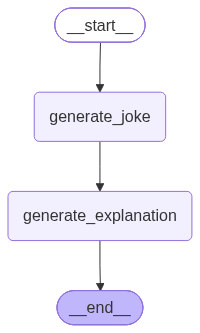

In [41]:
workflow

In [42]:
config1 = {'configurable':{'thread_id':"1"}}

initial_state = {
    'topic':'pizza'
}

final_state = workflow.invoke(initial_state,config=config1)

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6a5ee460-738cacd7264ccb5c45906f2d;6c32fd3a-7178-4bca-9337-e8d9bf0c1f22)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

In [ ]:
final_state

{'topic': 'pizza',
 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling a little crusty under the pressure! (get it?)",
 'explanation': 'A delightful pizza pun!\n\nThe joke relies on a play on words, using the phrase "crusty" (which has a double meaning) to create a pun. Here\'s a breakdown of the explanation:\n\n* The setup is a common joke format, asking "Why did the pizza go to therapy?" which implies that the pizza is a person and can have emotions and experiences.\n* The punchline is "Because it was feeling a little crusty under the pressure!" which is a play on words. "Crusty" has a double meaning here:\n\t+ A pizza crust is the hard outer layer of a pizza, which is a literal reference to the food.\n\t+ "Crusty" can also mean being irritable or having a bad temper, which is a figurative way of describing someone\'s emotional state.\n* The wordplay is that the joke takes the literal meaning of "crusty" (the pizza crust) and turns it into a figurative

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Here's one:\n\nWhy did the pizza go to therapy?\n\nBecause it was feeling a little crusty under the pressure! (get it?)", 'explanation': 'A delightful pizza pun!\n\nThe joke relies on a play on words, using the phrase "crusty" (which has a double meaning) to create a pun. Here\'s a breakdown of the explanation:\n\n* The setup is a common joke format, asking "Why did the pizza go to therapy?" which implies that the pizza is a person and can have emotions and experiences.\n* The punchline is "Because it was feeling a little crusty under the pressure!" which is a play on words. "Crusty" has a double meaning here:\n\t+ A pizza crust is the hard outer layer of a pizza, which is a literal reference to the food.\n\t+ "Crusty" can also mean being irritable or having a bad temper, which is a figurative way of describing someone\'s emotional state.\n* The wordplay is that the joke takes the literal meaning of "crusty" (the pizza crust) and turns i

In [43]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f184b27-5df3-6cd5-8000-3b0d3ea41710'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-21T03:15:44.180529+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f184b27-5de9-6fc0-bfff-56fe61e4015b'}}, tasks=(PregelTask(id='3209dfef-d3ac-72ee-9053-34fe91f13add', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='HfHubHTTPError("Client error \'402 Payment Required\' for url \'https://router.huggingface.co/v1/chat/completions\' (Request ID: Root=1-6a5ee460-738cacd7264ccb5c45906f2d;6c32fd3a-7178-4bca-9337-e8d9bf0c1f22)\\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402\\n\\nYou have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to P

In [44]:
config2 = {'configurable':{'thread_id':"2"}}
workflow.invoke({'topic':'pasta & Pizza'},config=config2)

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6a5ee462-36b7a6e368e12e4325aed7c5;f82df9e9-6fc0-41c9-8fa9-c83f2deb2f0d)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

In [45]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta & Pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f184b27-702d-65c1-8000-21a573edd0d9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-21T03:15:46.091551+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f184b27-702b-6044-bfff-89e99c3ecf38'}}, tasks=(PregelTask(id='327dbf77-4ed3-16a7-2390-e3a17869a212', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='HfHubHTTPError("Client error \'402 Payment Required\' for url \'https://router.huggingface.co/v1/chat/completions\' (Request ID: Root=1-6a5ee462-36b7a6e368e12e4325aed7c5;f82df9e9-6fc0-41c9-8fa9-c83f2deb2f0d)\\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402\\n\\nYou have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscr

In [46]:
workflow.get_state({'configurable':{'thread_id':"2",'checkpoint_id':"1f184482-fc9a-665d-8005-735701ab41a0"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f184482-fc9a-665d-8005-735701ab41a0'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [26]:
workflow.invoke(None,{'configurable':{'thread_id':"2",'checkpoint_id':"1f184482-fc9a-665d-8005-735701ab41a0"}})

{'topic': 'pasta & Pizza',
 'joke': "Here's a joke for you:\n\nWhy did the pasta and pizza go to therapy together?\n\nBecause the pasta was feeling saucy and the pizza was crusty under the pressure! (get it?)",
 'explanation': 'A play on words!\n\nThe joke relies on a double meaning of the words "saucy" and "crusty" to create a pun. In this context, "saucy" has a dual meaning:\n\n1. In a playful or cheeky way (e.g., "She was being a bit saucy and answered back").\n2. Having a strong or overpowering flavor, characteristic of tomato sauce (e.g., "This pasta dish has a saucy flavor").\n\nSimilarly, "crusty" has a dual meaning:\n\n1. Having a rough or hardened exterior (e.g., "The old crusty bread was perfect for dipping").\n2. Referring to the crust on a pizza, which is a characteristic of the dish.\n\nThe punchline of the joke plays on these dual meanings, using wordplay to create a clever and humorous connection between the pasta\'s emotional state and the pizza\'s crust. The therapist 

In [27]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta & Pizza', 'joke': "Here's a joke for you:\n\nWhy did the pasta and pizza go to therapy together?\n\nBecause the pasta was feeling saucy and the pizza was crusty under the pressure! (get it?)", 'explanation': 'A play on words!\n\nThe joke relies on a double meaning of the words "saucy" and "crusty" to create a pun. In this context, "saucy" has a dual meaning:\n\n1. In a playful or cheeky way (e.g., "She was being a bit saucy and answered back").\n2. Having a strong or overpowering flavor, characteristic of tomato sauce (e.g., "This pasta dish has a saucy flavor").\n\nSimilarly, "crusty" has a dual meaning:\n\n1. Having a rough or hardened exterior (e.g., "The old crusty bread was perfect for dipping").\n2. Referring to the crust on a pizza, which is a characteristic of the dish.\n\nThe punchline of the joke plays on these dual meanings, using wordplay to create a clever and humorous connection between the pasta\'s emotional state and the pizza\'s c

In [29]:
workflow.update_state({'configurable':{'thread_id':'2','checkpoint_id':'1f184481-9f52-63c5-8000-d937fa419610','checkpoint_ns':''}},{'topic':'somosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1844ac-2b62-6671-8001-4fe27a6bc4db'}}

In [31]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'somosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1844ac-2b62-6671-8001-4fe27a6bc4db'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-20T14:53:25.435923+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f184481-9f52-63c5-8000-d937fa419610'}}, tasks=(PregelTask(id='f05659d4-e1ff-81c7-0db6-4f8ad4946954', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta & Pizza', 'joke': "Here's a joke for you:\n\nWhy did the pasta and pizza go to therapy together?\n\nBecause the pasta was feeling saucy and the pizza was crusty under the pressure! (get it?)", 'explanation': 'A play on words!\n\nThe joke relies on a double meaning of the words "saucy" and "crusty" to create a pun. In this context, "saucy" 

In [34]:
workflow.invoke(None,{'configurable':{'thread_id':"2",'checkpoint_id':'1f1844ac-2b62-6671-8001-4fe27a6bc4db'}})

{'topic': 'somosa',
 'joke': 'Here\'s a joke for you:\n\nWhy did the samosa go to therapy?\n\nBecause it was feeling a little "wrapped up" in its problems!',
 'explanation': 'A clever play on words!\n\nThe joke is a pun, and it relies on a bit of wordplay. "Wrapped up" is an idiomatic expression that means feeling anxious or overwhelmed by one\'s problems. However, in this joke, the phrase "wrapped up" is also a literal reference to the fact that a samosa is a type of Indian pastry that is typically wrapped in a thin dough wrapper before being fried or baked.\n\nThe humor comes from the unexpected twist on the usual meaning of "wrapped up," and the clever way the joke uses the samosa\'s characteristic wrapping to create a wordplay that connects the setup to the punchline. It\'s a lighthearted and clever play on words that requires a quick mental shift to understand the pun.'}